In [8]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [9]:
# Load images and make them 128 by 128
def load_images_from_folder(folder, img_size=(128, 128)):
    images = []
    labels = []
    for label in os.listdir(folder):
        if label not in classes:
            continue
        label_folder = os.path.join(folder, label)
        for filename in os.listdir(label_folder):
            img_path = os.path.join(label_folder, filename)
            img = Image.open(img_path).convert('RGB')
            img = img.resize(img_size)
            img = np.array(img) / 255.0
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

classes = ['sandstorm', 'lightning', 'hail', 'rain', 'snow', 'frost']
num_classes = len(classes)

# Load dataset
data_folder = 'dataset1'
images, labels = load_images_from_folder(data_folder)

# Convert string labels to integers
label_to_int = {label: idx for idx, label in enumerate(classes)}
y = np.array([label_to_int[label] for label in labels])

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(images, y, test_size=0.2, random_state=42)

# Convert integer labels to one-hot encoded vectors
y_train_one_hot = to_categorical(y_train, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test, num_classes=num_classes)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,414 (12.61 MB)

 Trainable params: 3,305,414 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 201ms/step - accuracy: 0.4138 - loss: 1.5245 - val_accuracy: 0.6743 - val_loss: 0.9395
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 16s 190ms/step - accuracy: 0.7119 - loss: 0.7718 - val_accuracy: 0.6636 - val_loss: 0.8750
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 16s 191ms/step - accuracy: 0.7170 - loss: 0.7707 - val_accuracy: 0.7032 - val_loss: 0.7938
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.7873 - loss: 0.5739 - val_accuracy: 0.7123 - val_loss: 0.7699
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step - accuracy: 0.8209 - loss: 0.4898 - val_accuracy: 0.6758 - val_loss: 0.9361
Epoch 6/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.8410 - loss: 0.4518 - val_accuracy: 0.7412 - val_loss: 0.7687
Epoch 7/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.8846 - loss: 0.3408 - val_accuracy: 0.7184 - val_loss: 0.9252
Epoch 8/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.8981 - loss: 0.2985 - val_accuracy: 0.71

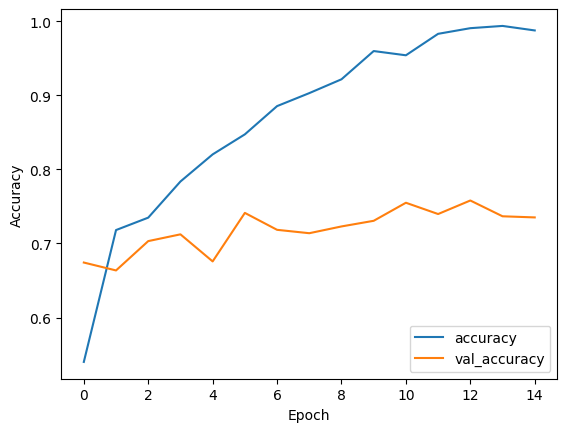

In [10]:
# Build the CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(6, activation='softmax')
])

# Display the model summary
model.summary()

model.compile(optimizer='adam',
              loss='categorical_crossentropy',  # Use categorical_crossentropy for one-hot encoding
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train_one_hot, epochs=15, validation_data=(X_test, y_test_one_hot))

# Plot training and validation accuracy and loss
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

# Save the model
model.save('weather_classifier_model.h5')

In [12]:
# Load the trained model
model = load_model('weather_classifier_model.h5')

# Function to preprocess the uploaded image
def preprocess_image(image_path, img_size=(128, 128)):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(img_size)
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)  # Add batch dimension
    return img

weather_labels = ['sandstorm', 'lightning', 'hail', 'rain', 'snow', 'frost']

# Function to classify the image
def classify_image():
    file_path = filedialog.askopenfilename()
    if file_path:
        img = preprocess_image(file_path)
        prediction = model.predict(img)
        predicted_class = np.argmax(prediction)
        confidence = np.max(prediction)
        # Map the predicted class index to the corresponding weather label
        predicted_label = weather_labels[predicted_class]
        result_label.config(text=f'Predicted Class: {predicted_label}, Confidence: {confidence:.2f}')

# Create the Tkinter interface
root = tk.Tk()
root.title("Weather Classification App")

upload_button = tk.Button(root, text="Upload Image", command=classify_image)
upload_button.pack(pady=20)

result_label = tk.Label(root, text="Predicted Class: None, Confidence: 0.00")
result_label.pack(pady=20)

root.mainloop()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
